In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import re
from collections import Counter

#### **CONTEXTO E OBJETIVO**
* Os dados foram obtidos a partir do consumo da API da Gupy.
* O objetivo é analisar o mercado de vagas de dados dentro desse contexto. 
* Como está o mercado recentemente?

**Labels** utilizadas para obtenção de arquivos: <br>
* analista
* dados
* python
* administração
* engenharia
* desenvolvedor
* engenheiro
* cientista
* ciência
* bi
* analyst
* engineer
* scientist
* business
* devops
* back-end

In [33]:
# leitura dos múltiplos arquivos JSONS
path = Path ("../dados/raw")

files = list(path.glob("*json"))

dfs = []

for file in files:
    df = pd.read_json(file)
    dfs.append(df)

arquivo_dados = pd.concat(dfs, ignore_index=True)
arquivo_dados.head

<bound method NDFrame.head of           id  companyId                                               name  \
0    9682376      73231   Assistente de Administração Logística - Brasília   
1    9682205      73231  Assistente de Administração Logística - Aparec...   
2    9676345        175  Administrador(a) de Contrato de Suprimentos (C...   
3    9658023      28978            Banco de Talentos - Área: Administração   
4    9507452      75673  Professor de Curso Técnico em Administração | ...   
..       ...        ...                                                ...   
833  3276160      26767              Banco de Talentos - Software Engineer   
834  2797695       1186  Desenvolvedor de Software Júnior - Exclusivo p...   
835  1736850      20893  Analista da Garantia de Qualidade de Software ...   
836  1729070      20893                              ARQUITETO DE SOFTWARE   
837   941147       1243                          Desenvolvedor(a) Software   

                                 

In [34]:
df_dados = arquivo_dados[arquivo_dados["name"].str.contains("dados", case=False, na=False) |
                         arquivo_dados["description"].str.contains("dados", case=False, na=False)]
df_dados = df_dados.drop_duplicates(subset="id")
df_dados.count()

id                     312
companyId              312
name                   312
description            312
careerPageId           312
careerPageName         312
careerPageLogo         312
type                   312
publishedDate          312
applicationDeadline     60
isRemoteWork           312
city                   312
state                  312
country                312
jobUrl                 312
badges                 312
disabilities           312
workplaceType          288
careerPageUrl          312
dtype: int64

In [35]:
#df_dados

In [36]:
df_dados.columns

Index(['id', 'companyId', 'name', 'description', 'careerPageId',
       'careerPageName', 'careerPageLogo', 'type', 'publishedDate',
       'applicationDeadline', 'isRemoteWork', 'city', 'state', 'country',
       'jobUrl', 'badges', 'disabilities', 'workplaceType', 'careerPageUrl'],
      dtype='str')

In [37]:
df_dados_limpo = df_dados.drop(columns=["id","companyId", "careerPageId", "careerPageLogo",
                                   "publishedDate", "applicationDeadline", "isRemoteWork",
                                   "country","jobUrl", "badges", "disabilities", "careerPageUrl"])
df_dados_limpo

,name,description,careerPageName,type,city,state,workplaceType
4,Professor de Curso Técnico em Administração | ...,[Vaga para Banco de Talentos]🌟&nbsp;Seja parte...,Tom Educação,vacancy_type_talent_pool,Foz do Iguaçu,Paraná,on-site
6,Professor de Curso Técnico em Administração | ...,[Vaga para Banco de Talentos]🌟&nbsp;Seja parte...,Tom Educação,vacancy_type_talent_pool,Curitiba,Paraná,on-site
7,Professor de Curso Técnico em Administração | ...,[Vaga para Banco de Talentos]🌟&nbsp;Seja parte...,Tom Educação,vacancy_type_talent_pool,Londrina,Paraná,on-site
13,ADMINISTRADOR,Você quer fazer parte da equipe Qualidados?&nb...,Qualidados,vacancy_type_talent_pool,Salvador,Bahia,on-site
18,ANALISTA DE ADMINISTRAÇÃO PESSOAL II - FOCO EM...,"Olá, somos a Cruzeiro do Sul Educacional! ⭐&nb...",Universidade Cruzeiro do Sul,vacancy_type_effective,São Paulo,São Paulo,on-site
...,...,...,...,...,...,...,...
815,Estágio em Desenvolvimento de Software Frontend,Vamos buscar o extraordinário juntos? 🚀Nossos ...,Franq,vacancy_type_internship,Florianópolis,Santa Catarina,on-site
822,Banco de Talentos - QA Software Tester,"A Wise tem a missão de transformar empresas, o...",Wise Group,vacancy_type_talent_pool,Curitiba,Paraná,hybrid
826,SOFTWARE DEVELOPER JUNIOR - .NET | REMOTO,LOCALIZASomos uma empresa presente no futuro. ...,Localiza&Co,vacancy_type_talent_pool,,,remote
829,Coordenador de Desenvolvimento de Software,Sobre NósSomos um grupo de pessoas que se enca...,Grupo Morada,vacancy_type_effective,Natal,Rio Grande do Norte,NaN


In [38]:
df_dados_limpo["state"] = df_dados_limpo["state"].replace("", np.nan)
df_dados_limpo[df_dados_limpo["state"].isna()]

,name,description,careerPageName,type,city,state,workplaceType
41,Analista de Dados III | BI | Azure,UTILIZE A SUA PAIXÃO POR TECNOLOGIA PARA CAUSA...,Lumini IT Solutions,vacancy_legal_entity,,NaN,remote
44,Analista de Laboratório,Você está se candidatando para o nosso banco d...,Rede Américas,vacancy_type_talent_pool,,NaN,on-site
59,ANALISTA PLENO DE BI,"A hora de fazer parte de um time comprometido,...",Página de Carreira,vacancy_type_effective,,NaN,remote
111,Analista de Laboratório - Setor Genética,Vem ser Dasa. Somos a maior rede de saúde inte...,Dasa,vacancy_type_talent_pool,,NaN,on-site
112,Analista de Laboratório,Você tem paixão pelas pessoas e gosta de cuida...,Dasa,vacancy_type_talent_pool,,NaN,on-site
114,Analista Financeiro,Você está se candidatando para o nosso banco d...,Rede Américas,vacancy_type_talent_pool,,NaN,on-site
153,Analista de Sistemas - TDM,Somos a maior multinacional brasileira e estam...,Stefanini Group,vacancy_type_effective,,NaN,remote
161,Analista Machine Learning/Python,Somos a maior multinacional brasileira e estam...,Stefanini Group,vacancy_type_effective,,NaN,remote
189,Analista de Business Intelligence,Nossos valores moldam a cultura da nossa organ...,QiBit Vagas,vacancy_type_effective,,NaN,remote
195,Analista de BI Pleno - POWER BI,"Como Analista de BI Pleno na Montreal, você fa...",Montreal | Tecnologia e Inovação,vacancy_type_effective,,NaN,remote


In [39]:
df_dados_limpo.loc[df_dados_limpo["city"].str.contains("Belo Horizonte", na=False), "state"] = "Minas Gerais"
df_dados_limpo[df_dados_limpo["state"].isna()]

,name,description,careerPageName,type,city,state,workplaceType
41,Analista de Dados III | BI | Azure,UTILIZE A SUA PAIXÃO POR TECNOLOGIA PARA CAUSA...,Lumini IT Solutions,vacancy_legal_entity,,NaN,remote
44,Analista de Laboratório,Você está se candidatando para o nosso banco d...,Rede Américas,vacancy_type_talent_pool,,NaN,on-site
59,ANALISTA PLENO DE BI,"A hora de fazer parte de um time comprometido,...",Página de Carreira,vacancy_type_effective,,NaN,remote
111,Analista de Laboratório - Setor Genética,Vem ser Dasa. Somos a maior rede de saúde inte...,Dasa,vacancy_type_talent_pool,,NaN,on-site
112,Analista de Laboratório,Você tem paixão pelas pessoas e gosta de cuida...,Dasa,vacancy_type_talent_pool,,NaN,on-site
114,Analista Financeiro,Você está se candidatando para o nosso banco d...,Rede Américas,vacancy_type_talent_pool,,NaN,on-site
153,Analista de Sistemas - TDM,Somos a maior multinacional brasileira e estam...,Stefanini Group,vacancy_type_effective,,NaN,remote
161,Analista Machine Learning/Python,Somos a maior multinacional brasileira e estam...,Stefanini Group,vacancy_type_effective,,NaN,remote
189,Analista de Business Intelligence,Nossos valores moldam a cultura da nossa organ...,QiBit Vagas,vacancy_type_effective,,NaN,remote
195,Analista de BI Pleno - POWER BI,"Como Analista de BI Pleno na Montreal, você fa...",Montreal | Tecnologia e Inovação,vacancy_type_effective,,NaN,remote


In [40]:
df_dados_limpo = df_dados_limpo.drop(columns=["city"])
#df_dados_limpo

In [41]:
df_dados_limpo = df_dados_limpo.dropna()
df_dados_limpo

,name,description,careerPageName,type,state,workplaceType
4,Professor de Curso Técnico em Administração | ...,[Vaga para Banco de Talentos]🌟&nbsp;Seja parte...,Tom Educação,vacancy_type_talent_pool,Paraná,on-site
6,Professor de Curso Técnico em Administração | ...,[Vaga para Banco de Talentos]🌟&nbsp;Seja parte...,Tom Educação,vacancy_type_talent_pool,Paraná,on-site
7,Professor de Curso Técnico em Administração | ...,[Vaga para Banco de Talentos]🌟&nbsp;Seja parte...,Tom Educação,vacancy_type_talent_pool,Paraná,on-site
13,ADMINISTRADOR,Você quer fazer parte da equipe Qualidados?&nb...,Qualidados,vacancy_type_talent_pool,Bahia,on-site
18,ANALISTA DE ADMINISTRAÇÃO PESSOAL II - FOCO EM...,"Olá, somos a Cruzeiro do Sul Educacional! ⭐&nb...",Universidade Cruzeiro do Sul,vacancy_type_effective,São Paulo,on-site
...,...,...,...,...,...,...
805,Software Engineer - Ruby on Rails,Vem ser MobThinker!Responsabilidades e atribui...,Mesa Mobile Thinking,vacancy_type_effective,Pernambuco,remote
807,Banco de Talentos - Software Engineer,"O que nos torna Mobthinkers raiz, é estarmos c...",Mesa Mobile Thinking,vacancy_type_effective,Pernambuco,remote
813,Banco de Talentos WK Technology - Desenvolvime...,Banco de Talentos WK Technology Desenvolviment...,WK Technology,vacancy_type_talent_pool,Santa Catarina,remote
815,Estágio em Desenvolvimento de Software Frontend,Vamos buscar o extraordinário juntos? 🚀Nossos ...,Franq,vacancy_type_internship,Santa Catarina,on-site


In [42]:
valores_unicos_type = df_dados_limpo["type"].unique()
valores_unicos_type

<ArrowStringArray>
['vacancy_type_talent_pool',   'vacancy_type_effective',
   'vacancy_type_temporary',     'vacancy_legal_entity',
  'vacancy_type_autonomous',  'vacancy_type_internship',
   'vacancy_type_outsource']
Length: 7, dtype: str

In [43]:
def normalize_type(value):
    mapping = {
        "vacancy_type_talent_pool": "banco de talentos",
        "vacancy_type_effective": "CLT",
        "vacancy_legal_entity": "PJ",
        "vacancy_type_internship": "estágio"
    }
    return mapping.get(value, "freelancer")

df_dados_limpo["type"] = df_dados_limpo["type"].apply(normalize_type)

In [44]:
def traducao_workplaceType(value):
    mapping = {
        "on-site": "presencial",
        "hybrid": "híbrido",
    }
    return mapping.get(value, "remoto")

df_dados_limpo["workplaceType"] = df_dados_limpo["workplaceType"].apply(traducao_workplaceType)

Para análise, foi filtrado apenas as vagas com **"dados"** em nome e/ou descrição. <br>

Etapas: 
* retirada de duplicatas
* retirada de colunas:"id","companyId", "careerPageId", "careerPageLogo", "publishedDate", "applicationDeadline", "isRemoteWork", "country","jobUrl", "badges", "disabilities", "careerPageUrl" e "city"
* retirada de valores nulos (NaN)
* padronização dos valores do tipo de trabalho ("type")


**Antes:** 439 linhas e 19 colunas <br>
**Depois:** 136 linhas e 6 colunas <br>

In [45]:
df_dados_limpo.to_csv("../dados/processed/dados_total_limpo.csv", index=False)
df_dados_limpo.to_parquet("../dados/processed/dados_total_limpo.parquet",index=False)
#df_dados_limpo

### **ANÁLISE EXPLORATÓRIA DE DADOS (EDA)**

In [46]:
df_dados_limpo.describe()

,name,description,careerPageName,type,state,workplaceType
count,239,239,239,239,239,239
unique,229,236,110,5,19,3
top,Analista de Dados,[Vaga para Banco de Talentos]🌟&nbsp;Seja parte...,Qualidados,CLT,São Paulo,presencial
freq,3,2,23,117,121,147


**VISÃO GERAL DOS DADOS:**
* 131 de 138 títulos de vagas são únicos
* 137 de 138 descrições são únicas
* 5 tipos de contratação (CLT, PJ, banco de talentos, etc.)
* 16 estados representados
* 3 modelos de trabalho (presencial, remoto e híbrido)

**DESTAQUES:**
* Título mais frequente: **Analista de dados**
* Empresa com mais vagas: **Qualidados (10/138)**
* Tipo de contratação mais comum: **CLT (83/138)**
* Estado com mais vagas: **São Paulo (77/138)**
* Modelo de trabalho mais comum: **Presencial (100/138)**

### Palavras mais frequentes (Descrição)

In [47]:
#juntar todas as descrições para buscar as palavras-chave mais frequentes
text = " ".join(df_dados_limpo["description"].dropna())
text = text.lower()
text = re.sub(r"[^\w\s]", "", text) #para remover a pontuação

In [48]:
words = text.split()

In [49]:
stopwords = {
    "de", "da", "do", "e", "a", "o", "em", "para", "com", "busca",
    "que", "você", "nosso", "nossos", "nossas", "dos",
    "uma", "data", "por", "seu", "empresa", "soluções", "muito",
    "pessoas", "são", "todos", "nos", "não", "vagas", "vida",
    "fazer", "das", "sua", "como", "mais", "profissional", "power",
    "time", "áreas", "somos", "parte", "qualidade", "melhor",
    "nossa", "estamos", "mundo", "clientes", "eou", "análises",
    "pela", "seus", "gênero", "responsável", "área", "ser", "sempre",
    "experience", "ferramentas", "100", "trabalho", "melhores", "dia",
    "and", "sobre", "aos", "superior", "trabalhar"
}

words = [w for w in words if w not in stopwords and len(w) > 2]

In [50]:
words_series = pd.Series(words)
counts = words_series.value_counts().head(20).sort_values(ascending=False)
counts

dados              425
desenvolvimento    246
processos          167
equipe             161
experiência        160
projetos           146
conhecimento       139
processo           135
sistemas           135
gestão             127
saúde              122
engenharia         115
ambiente           110
serviços           110
produtos           108
banco              107
informações        103
atividades         103
análise            102
comunicação         97
Name: count, dtype: int64

### Palavras mais frequentes (Título da vaga)

In [51]:
valores_unicos_name = df_dados_limpo["name"].unique()
valores_unicos_name

<ArrowStringArray>
[            'Professor de Curso Técnico em Administração | Foz do Iguaçu [Banco de Talentos 2025]',
                  'Professor de Curso Técnico em Administração | Curitiba [Banco de Talentos 2025]',
 'Professor de Curso Técnico em Administração | Londrina, Cambé e Ibiporã [Banco de Talentos 2025]',
                                                                                   'ADMINISTRADOR ',
                                'ANALISTA DE ADMINISTRAÇÃO PESSOAL II - FOCO EM ADMISSÃO E FÉRIAS ',
                                          'Analista de Planejamento Financeiro Sr. (Foco em Dados)',
                                                                         'Analista de Laboratório ',
                                                           'Analista de Planejamento Comercial Sr.',
                                                           'Analista de Planejamento Comercial Jr.',
                                'Analista de Inteligência Comercial II |

In [52]:
text_name = " ".join(df_dados_limpo["name"].dropna())
text_name = text_name.lower()
text_name = re.sub(r"[^\w\s]", "", text_name) #para remover a pontuação

words_name = text_name.split()

stopwords = {
    "de", "da", "do", "e", "a", "o", "em", "para", "com", "busca",
    "que", "você", "dados", "nosso", "nossos", "nossas", "dos",
    "uma", "data", "por", "seu", "empresa", "soluções", "muito",
    "pessoas", "são", "todos", "nos", "não", "vagas", "vida",
    "fazer", "das", "sua", "como", "mais", "power",
    "time", "áreas", "somos", "parte", "melhor",
    "nossa", "estamos", "mundo", "clientes", "eou", "análises",
    "pela", "seus", "gênero", "responsável", "área", "ser", "sempre",
    "experience", "ferramentas", "100", "trabalho", "melhores", "dia",
    "and", "sobre", "aos", "superior", "trabalhar"
}

words_name = [w for w in words_name if w not in stopwords and len(w) > 2]

In [53]:
words_series_name = pd.Series(words_name)
counts_name = words_series_name.value_counts().head(20).sort_values(ascending=False)
counts_name

analista          121
banco              33
talentos           32
desenvolvedor      28
engenheiro         24
pessoa             20
pleno              18
java               16
desenvolvedora     16
planejamento       14
backend            12
sênior             11
engenharia          9
comercial           8
software            8
técnico             7
2025                7
administrativo      7
júnior              7
professor           6
Name: count, dtype: int64

### **COMO É O MERCADO DE VAGAS DE DADOS?** 
**Contexto da análise:**
* Coleta de dados realizada a partir da API da Gupy utilizando as seguintes palavras-chave:
*"analista", "dados", "python", "administração", "engenharia", "desenvolvedor", "engenheiro", "cientista", "ciência", "bi", "analyst", "engineer", "scientist", "business", "devops", "back-end"*
* Aplicação de filtro adicional considerando a presença do termo **"dados"** no nome ou na descrição das vagas
* Base final composta por **138 vagas**, após etapas de tratamento e limpeza dos dados

### Qual o modelo de trabalho mais comum?

In [54]:
df_dados_limpo.columns

Index(['name', 'description', 'careerPageName', 'type', 'state',
       'workplaceType'],
      dtype='str')

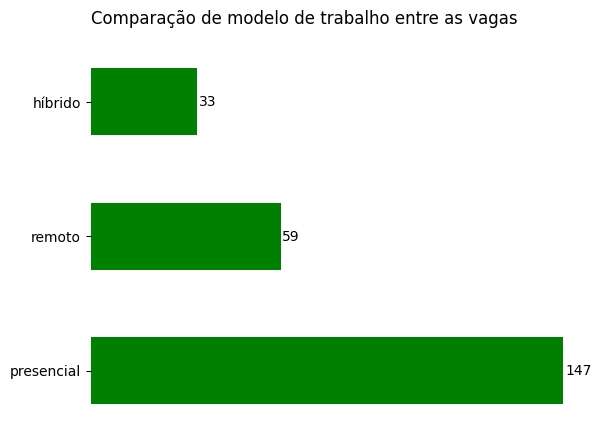

In [55]:
fig, ax = plt.subplots()

counts = df_dados_limpo["workplaceType"].value_counts()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('Comparação de modelo de trabalho entre as vagas', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

O modelo presencial é amplamente predominante no dataset, representando aproximadamente **72% das vagas**.

Isso pode indicar que:
* muitas empresas ainda priorizam atuação local
* algumas áreas de dados estão integradas a operações presenciais
* ou há limitação da própria plataforma/amostra coletada

Observa-se predominância do modelo presencial na amostra analisada, o que pode refletir o perfil das empresas na plataforma ou o tipo de vaga coletada.

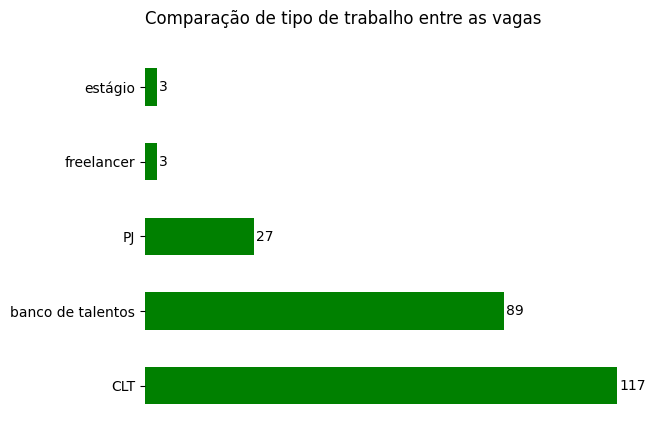

In [56]:
fig, ax = plt.subplots()

counts = df_dados_limpo["type"].value_counts()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('Comparação de tipo de trabalho entre as vagas', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

O regime **CLT é dominante**, mas há uma presença relevante de vagas em **banco de talentos (44)**.

Isso sugere que:
* parte das vagas pode não representar posições imediatas, mas sim formação de pipeline de candidatos.

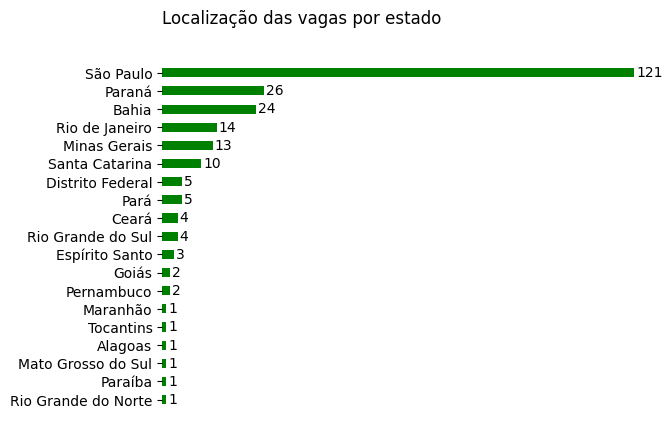

In [57]:
fig, ax = plt.subplots()

counts = df_dados_limpo["state"].value_counts()
counts = counts.sort_values()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('Localização das vagas por estado', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

Há forte concentração em **São Paulo**, o que pode refletir:
* maior concentração de empresas
* maior adoção da plataforma Gupy na região

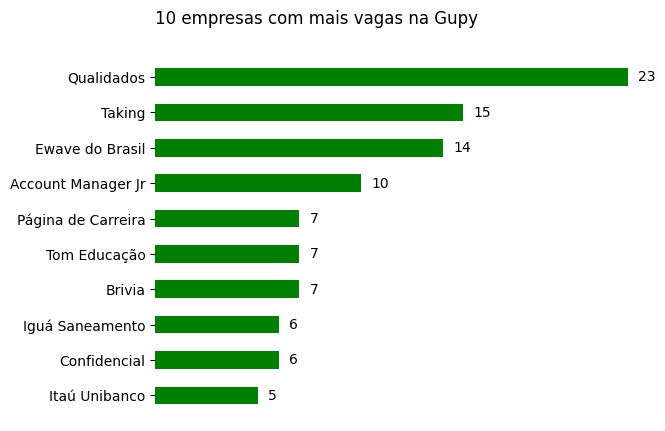

In [58]:
fig, ax = plt.subplots()

counts = df_dados_limpo["careerPageName"].value_counts().head(10)
counts = counts.sort_values()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('10 empresas com mais vagas na Gupy', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

Não há alta concentração em poucas empresas.
Mesmo as empresas com mais vagas representam uma fração pequena do total, indicando uma distribuição relativamente dispersa entre diferentes organizações.

**Observação importante:**
* A análise está limitada às empresas que utilizam a plataforma Gupy.

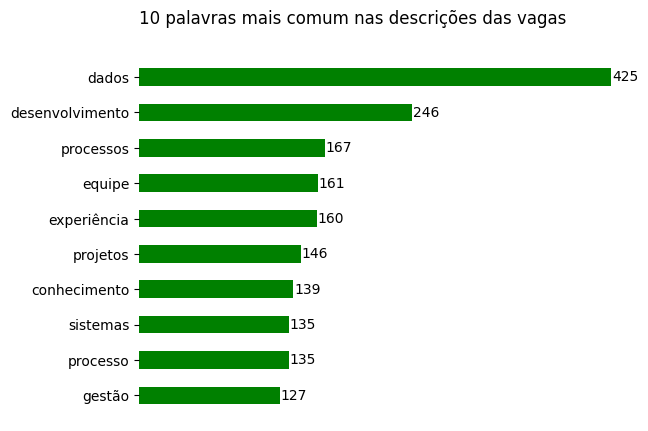

In [59]:
fig, ax = plt.subplots()

counts = pd.Series(words).value_counts().head(10)
counts = counts.sort_values()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('10 palavras mais comum nas descrições das vagas', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

As descrições indicam que:
* as descrições indicam que muitas vagas combinam atividades analíticas com funções operacionais, de suporte e gestão de processos.

Também há forte presença de termos como:
* equipe
* comunicação
* experiência
Indicando valorização de soft skills

**Observação:**
* a frequência da palavra "saúde" sugere possível presença de empresas ou benefícios relacionados ao setor, mas não é suficiente para afirmar uma concentração de vagas nesse segmento.

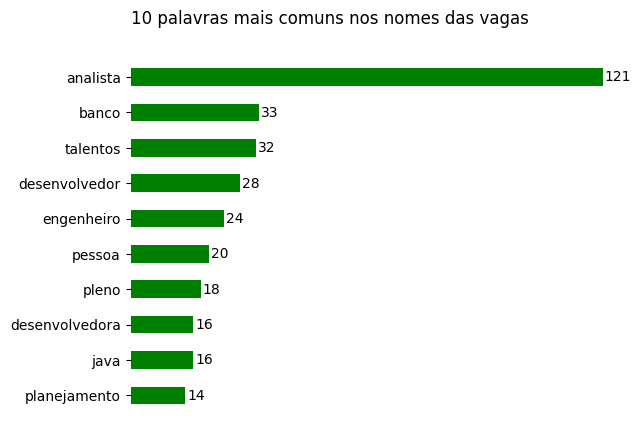

In [60]:
fig, ax = plt.subplots()

counts = pd.Series(words_name).value_counts().head(10)
counts = counts.sort_values()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('10 palavras mais comuns nos nomes das vagas', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

* O termo **“analista” domina**, indicando uso genérico para diferentes funções
* Há presença de níveis (júnior, pleno, sênior), mas não de forma consistente
* A combinação “banco” + “talentos” reforça a presença de vagas não imediatas

In [61]:
# Estado x Modelo de trabalho
pd.crosstab(
    df_dados_limpo["state"],
    df_dados_limpo["workplaceType"],
    normalize="index"
)

workplaceType,híbrido,presencial,remoto
state,,,
Alagoas,0.000000,1.000000,0.000000
Bahia,0.083333,0.916667,0.000000
Ceará,0.000000,1.000000,0.000000
Distrito Federal,0.200000,0.800000,0.000000
Espírito Santo,0.333333,0.666667,0.000000
Goiás,0.000000,1.000000,0.000000
Maranhão,0.000000,1.000000,0.000000
Mato Grosso do Sul,0.000000,1.000000,0.000000
Minas Gerais,0.076923,0.846154,0.076923


* Predominância forte de vagas presenciais na maioria dos estados
* São Paulo concentra maior diversidade de modelos (vagas híbridas ~19% e remotas ~15%)
* Trabalho remoto ainda é limitado fora dos grandes centros
* Indícios de transição gradual para modelos híbridos ( O modelo híbrido aparece de forma consistente, porém minoritária, em alguns estados como Bahia, Minas Gerais, Paraná e Distrito Federal. Isso pode indicar uma transição gradual do modelo presencial para formatos mais flexíveis, ainda em estágio intermediário.)

**Observação:**
* Resultados podem ser influenciados pelo tamanho reduzido da amostra em alguns estados
* É importante destacar que alguns estados possuem baixo número de vagas na amostra, o que pode distorcer as proporções (ex.: estados com 100% presencial podem ter apenas 1 ou 2 vagas). Portanto, os resultados devem ser interpretados com cautela

In [62]:
# Tipo de trabalho x Modelo de trabalho
pd.crosstab(
    df_dados_limpo["type"],
    df_dados_limpo["workplaceType"],
    normalize="index"
)

workplaceType,híbrido,presencial,remoto
type,,,
CLT,0.170940,0.649573,0.179487
PJ,0.000000,0.296296,0.703704
banco de talentos,0.146067,0.651685,0.202247
estágio,0.000000,1.000000,0.000000
freelancer,0.000000,0.666667,0.333333


* Presencial domina em todos os tipos de concentração
* CLT é majoritariamente presencial, com baixa presença de remoto
* PJ apresenta maior flexibilidade, com uma distribuição mais equilibrada entre presencial (~57%) e remoto (~43%), sem ocorrência de modelo híbrido
* Estágios são exclusivamente presenciais na amostra
* Banco de talentos segue padrão semelhante ao CLT
* Resultados podem ser influenciados por baixa amostragem em algumas categorias

### CONCLUSÕES GERAIS
**Como é o mercado de vagas de dados (com base na amostra):**
* Forte predominância de vagas presenciais
* Maioria das vagas em regime CLT
* Alta concentração geográfica em São Paulo, que também apresenta maior diversidade de modelos de trabalho (presencial, híbrido e remoto)
* Presença significativa de bancos de talentos, indicando formação de pipeline de contratação futura
* Vagas com escopo mais amplo que análise de dados, incluindo:
    * processos
    * gestão
    * suporte
* Baixa ênfase explícita em ferramentas técnicas nas descrições
* Possível concentração em setores específicos, como saúde

**Relação entre tipo de contratação e modelo de trabalho:**
* Vagas CLT são majoritariamente presenciais, com baixa presença de rmeoto
* Vagas PJ apresentam maior flexibilidade, com maior proporção de trabalho remoto
* Trabalho remoto ficou limitado e concentrado nos estados de São Paulo, Rio de Janeiro e Santa Catarina

A predominância do modelo presencial (72%) sugere uma preferência das empresas por atuação local, possivelmente associada à natureza operacional de parte das vagas, ao nível de senioridade esperado ou à maturidade digital das organizações.

**Limitações da análise:**
* Dados coletados apenas da plataforma Gupy
* Amostra limitada (138 vagas)
* Dados representam um recorte temporal específico
* Uso de palavras-chave pode introduzir viés na coleta